# 0. Sobre a base de dados

A base foi retirada do site [O Sistema de Estimativas de Emissões e Remoções de Gases de Efeito Estufa (SEEG)](https://seeg.eco.br), que é uma plataforma que contém uma das maiores bases de emissões de gases do efeito estufa no mundo.
A base retirada se refere aos dados na região brasileira.

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore", message="Unknown extension is not supported*")

In [2]:
url = ".\\1-SEEG10_GERAL-BR_UF_2022.10.27-FINAL-SITE.xlsx"
dados_emissoes = pd.read_excel(url, sheet_name= 'GEE Estados')

In [3]:
dados_emissoes.head()

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,...,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,...,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,...,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,...,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,...,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000


In [4]:
dados_emissoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103312 entries, 0 to 103311
Data columns (total 63 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Nível 1 - Setor             103312 non-null  object 
 1   Nível 2                     103312 non-null  object 
 2   Nível 3                     103253 non-null  object 
 3   Nível 4                     90920 non-null   object 
 4   Nível 5                     100788 non-null  object 
 5   Nível 6                     97691 non-null   object 
 6   Emissão / Remoção / Bunker  103312 non-null  object 
 7   Gás                         103312 non-null  object 
 8   Estado                      97374 non-null   object 
 9   Atividade Econômica         102076 non-null  object 
 10  Produto                     37413 non-null   object 
 11  1970                        103312 non-null  float64
 12  1971                        103312 non-null  float64
 13  1972          

# 1. Tratamento de dados

Importante ter algumas noções dos dados que são apresentados na planilha do excel:

1. Remoções são os dados referentes a retirada do efeito estufa.
2. NCI são dados não contemplados no inventário nacional.
3. Bunkers são emissões de transporte marítmo e aéreo, o que não condiz com a emissão diretas dos estados.

In [5]:
dados_emissoes['Emissão / Remoção / Bunker'].unique()

array(['Emissão', 'Emissão NCI', 'Remoção NCI', 'Bunker', 'Remoção'],
      dtype=object)

In [6]:
dados_emissoes[dados_emissoes["Emissão / Remoção / Bunker"].isin(["Remoção NCI","Remoção"])]

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
23520,Agropecuária,Solos Manejados,Diretas,Variação dos Estoques de Carbono no Solo,Vegetal,Pastagem Bem Manejada,Remoção NCI,CO2 (t),RO,PEC,...,-1.434540e+07,-1.499358e+07,-1.543196e+07,-1.567070e+07,-1.630063e+07,-1.702215e+07,-1.740074e+07,-1.771914e+07,-1.767632e+07,-1.838895e+07
23521,Agropecuária,Solos Manejados,Diretas,Variação dos Estoques de Carbono no Solo,Vegetal,Pastagem Bem Manejada,Remoção NCI,CO2 (t),AC,PEC,...,-5.382949e+06,-5.524659e+06,-5.632429e+06,-5.765030e+06,-5.867354e+06,-5.942076e+06,-6.022000e+06,-6.002147e+06,-6.035591e+06,-6.459079e+06
23522,Agropecuária,Solos Manejados,Diretas,Variação dos Estoques de Carbono no Solo,Vegetal,Pastagem Bem Manejada,Remoção NCI,CO2 (t),AM,PEC,...,-3.450455e+06,-3.540294e+06,-3.545724e+06,-3.924546e+06,-4.626541e+06,-4.874199e+06,-4.849173e+06,-4.959540e+06,-5.106806e+06,-5.809814e+06
23523,Agropecuária,Solos Manejados,Diretas,Variação dos Estoques de Carbono no Solo,Vegetal,Pastagem Bem Manejada,Remoção NCI,CO2 (t),RR,PEC,...,-1.260166e+06,-1.261895e+06,-1.371664e+06,-1.501452e+06,-1.507705e+06,-1.509919e+06,-1.609826e+06,-1.616980e+06,-1.518397e+06,-1.926000e+06
23524,Agropecuária,Solos Manejados,Diretas,Variação dos Estoques de Carbono no Solo,Vegetal,Pastagem Bem Manejada,Remoção NCI,CO2 (t),PA,PEC,...,-3.429279e+07,-3.317185e+07,-3.281628e+07,-3.350720e+07,-3.557183e+07,-3.755308e+07,-4.134614e+07,-4.229403e+07,-4.275448e+07,-4.443440e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102751,Mudança de Uso da Terra e Floresta,Remoção por Vegetação Secundária,Pantanal,em Área Protegida,Vegetação nativa estável,Vegetação não florestal secundária -- Vegetaçã...,Remoção,CO2e (t) GWP-AR4,MS,AGROPEC,...,-7.513000e+04,-7.911900e+04,-8.695900e+04,-9.201400e+04,-9.149400e+04,-9.630200e+04,-9.202000e+04,-9.762300e+04,-1.015020e+05,-1.008910e+05
102752,Mudança de Uso da Terra e Floresta,Remoção por Vegetação Secundária,Pantanal,em Área Protegida,Vegetação nativa estável,Vegetação não florestal secundária -- Vegetaçã...,Remoção,CO2e (t) GWP-AR5,MT,AGROPEC,...,-9.523000e+03,-9.667000e+03,-1.000300e+04,-1.024200e+04,-1.027200e+04,-1.019100e+04,-1.046900e+04,-1.090400e+04,-1.104100e+04,-1.109500e+04
102753,Mudança de Uso da Terra e Floresta,Remoção por Vegetação Secundária,Pantanal,em Área Protegida,Vegetação nativa estável,Vegetação não florestal secundária -- Vegetaçã...,Remoção,CO2e (t) GWP-AR5,MS,AGROPEC,...,-7.513000e+04,-7.911900e+04,-8.695900e+04,-9.201400e+04,-9.149400e+04,-9.630200e+04,-9.202000e+04,-9.762300e+04,-1.015020e+05,-1.008910e+05
102754,Mudança de Uso da Terra e Floresta,Remoção por Vegetação Secundária,Pantanal,em Área Protegida,Vegetação nativa estável,Vegetação não florestal secundária -- Vegetaçã...,Remoção,CO2e (t) GWP-AR6,MT,AGROPEC,...,-9.523000e+03,-9.667000e+03,-1.000300e+04,-1.024200e+04,-1.027200e+04,-1.019100e+04,-1.046900e+04,-1.090400e+04,-1.104100e+04,-1.109500e+04


In [7]:
dados_emissoes.loc[dados_emissoes["Emissão / Remoção / Bunker"].isin(["Remoção NCI","Remoção"]), 1970:2021].max()

1970    0.0
1971    0.0
1972    0.0
1973    0.0
1974    0.0
1975    0.0
1976    0.0
1977    0.0
1978    0.0
1979    0.0
1980    0.0
1981    0.0
1982    0.0
1983    0.0
1984    0.0
1985    0.0
1986    0.0
1987    0.0
1988    0.0
1989    0.0
1990    0.0
1991    0.0
1992    0.0
1993    0.0
1994    0.0
1995    0.0
1996    0.0
1997    0.0
1998    0.0
1999    0.0
2000    0.0
2001    0.0
2002    0.0
2003    0.0
2004    0.0
2005    0.0
2006    0.0
2007    0.0
2008    0.0
2009    0.0
2010    0.0
2011    0.0
2012    0.0
2013    0.0
2014    0.0
2015    0.0
2016    0.0
2017    0.0
2018    0.0
2019    0.0
2020    0.0
2021    0.0
dtype: float64

In [8]:
dados_emissoes.loc[dados_emissoes["Emissão / Remoção / Bunker"] == "Bunker", "Estado"].unique()

array([nan], dtype=object)

In [9]:
dados_emissoes.loc[:,"Nível 1 - Setor":"Produto"].columns

Index(['Nível 1 - Setor', 'Nível 2', 'Nível 3', 'Nível 4', 'Nível 5',
       'Nível 6', 'Emissão / Remoção / Bunker', 'Gás', 'Estado',
       'Atividade Econômica', 'Produto'],
      dtype='object')

In [10]:
colunas_info = list(dados_emissoes.loc[:,"Nível 1 - Setor":"Produto"].columns)
colunas_info

['Nível 1 - Setor',
 'Nível 2',
 'Nível 3',
 'Nível 4',
 'Nível 5',
 'Nível 6',
 'Emissão / Remoção / Bunker',
 'Gás',
 'Estado',
 'Atividade Econômica',
 'Produto']

In [11]:
dados_emissoes.loc[:,1970:2021].columns

Index([1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005,
       2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2020, 2021],
      dtype='object')

In [12]:
colunas_emissao = list(dados_emissoes.loc[:,1970:2021].columns)
colunas_emissao

[1970,
 1971,
 1972,
 1973,
 1974,
 1975,
 1976,
 1977,
 1978,
 1979,
 1980,
 1981,
 1982,
 1983,
 1984,
 1985,
 1986,
 1987,
 1988,
 1989,
 1990,
 1991,
 1992,
 1993,
 1994,
 1995,
 1996,
 1997,
 1998,
 1999,
 2000,
 2001,
 2002,
 2003,
 2004,
 2005,
 2006,
 2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021]

In [13]:
dados_emissoes_ano = dados_emissoes.melt(id_vars=colunas_info, value_vars=colunas_emissao, var_name="Ano", value_name="Emissão")

In [14]:
dados_emissoes_ano

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,Produto,Ano,Emissão
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,NaN,1970,0.0
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,NaN,1970,6210.0
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,NaN,1970,368.0
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,NaN,1970,115.0
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1970,1925100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5372219,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GTP-AR6,BR,NaN,NaN,2021,0.0
5372220,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR2,BR,NaN,NaN,2021,0.0
5372221,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR4,BR,NaN,NaN,2021,0.0
5372222,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pantanal,NaN,NaN,NaN,Emissão NCI,CO2e (t) GWP-AR5,BR,NaN,NaN,2021,0.0


In [15]:
dados_emissoes_ano.groupby("Gás")

In [16]:
dados_emissoes_ano.groupby("Gás").groups

{'C2F6 (t)': [410, 411, 412, 425, 426, 427, 103722, 103723, 103724, 103737, 103738, 103739, 207034, 207035, 207036, 207049, 207050, 207051, 310346, 310347, 310348, 310361, 310362, 310363, 413658, 413659, 413660, 413673, 413674, 413675, 516970, 516971, 516972, 516985, 516986, 516987, 620282, 620283, 620284, 620297, 620298, 620299, 723594, 723595, 723596, 723609, 723610, 723611, 826906, 826907, 826908, 826921, 826922, 826923, 930218, 930219, 930220, 930233, 930234, 930235, 1033530, 1033531, 1033532, 1033545, 1033546, 1033547, 1136842, 1136843, 1136844, 1136857, 1136858, 1136859, 1240154, 1240155, 1240156, 1240169, 1240170, 1240171, 1343466, 1343467, 1343468, 1343481, 1343482, 1343483, 1446778, 1446779, 1446780, 1446793, 1446794, 1446795, 1550090, 1550091, 1550092, 1550105, 1550106, 1550107, 1653402, 1653403, 1653404, 1653417, ...], 'CF4 (t)': [407, 408, 409, 422, 423, 424, 103719, 103720, 103721, 103734, 103735, 103736, 207031, 207032, 207033, 207046, 207047, 207048, 310343, 310344, 3103

In [17]:
dados_emissoes_ano.groupby("Gás").get_group("CO2 (t)")

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,Produto,Ano,Emissão
18,Processos Industriais,Indústria Química,Produção de Acrilonitrila,NaN,NaN,NaN,Emissão,CO2 (t),BA,OUTRA_IND,NaN,1970,0.000000
23,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,Emissão,CO2 (t),RJ,OUTRA_IND,NaN,1970,0.000000
26,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,Emissão,CO2 (t),MG,OUTRA_IND,NaN,1970,0.000000
29,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,Emissão,CO2 (t),BA,OUTRA_IND,NaN,1970,10742.465792
32,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,Emissão,CO2 (t),SE,OUTRA_IND,NaN,1970,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5372170,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Caatinga,NaN,NaN,NaN,Emissão NCI,CO2 (t),BR,NaN,NaN,2021,0.000000
5372181,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Cerrado,NaN,NaN,NaN,Emissão NCI,CO2 (t),BR,NaN,NaN,2021,0.000000
5372192,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Mata Atlântica,NaN,NaN,NaN,Emissão NCI,CO2 (t),BR,NaN,NaN,2021,0.000000
5372203,Mudança de Uso da Terra e Floresta,Queimadas Não Associadas a Desmatamento,Pampa,NaN,NaN,NaN,Emissão NCI,CO2 (t),BR,NaN,NaN,2021,0.000000


In [20]:
emissao_gas = dados_emissoes_ano.groupby("Gás").sum(numeric_only= True).sort_values("Emissão", ascending=False)

<Axes: ylabel='Gás'>

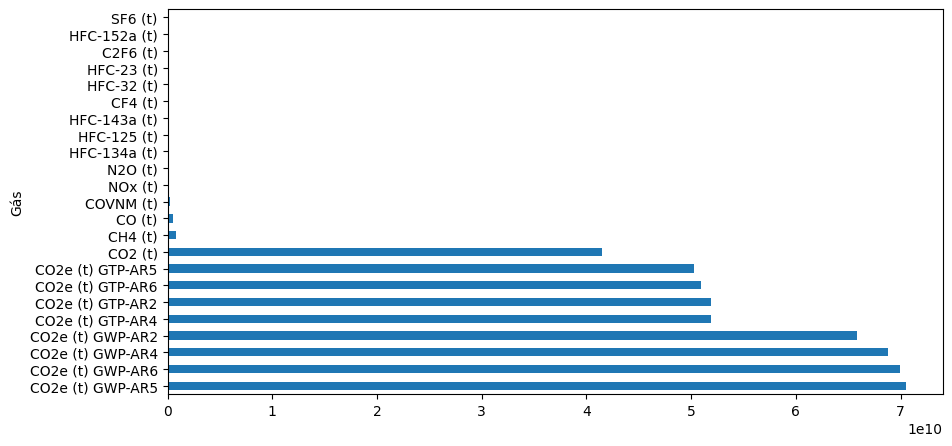

In [22]:
emissao_gas.plot(kind="barh", figsize=(10,5), legend=False)

In [25]:
emissao_co2 = emissao_gas.iloc[0:9].sum()
emissao_total = emissao_gas["Emissão"].sum()

In [27]:
emissao_co2

Emissão    5.217667e+11
dtype: float64

In [30]:
porcentagem_co2_total = emissao_co2/emissao_total
print(f"Emissão total de CO2: {emissao_co2} t")
print(f"Emissão total de gases: {emissao_total:.2f} t")
print(f"Porcentagem de CO2 em relação ao total: {porcentagem_co2_total}")   

Emissão total de CO2: Emissão    5.217667e+11
dtype: float64 t
Emissão total de gases: 523436282370.87 t
Porcentagem de CO2 em relação ao total: Emissão    0.99681
dtype: float64


In [31]:
gas_setor = dados_emissoes_ano.groupby(["Gás", "Nível 1 - Setor"]).sum(numeric_only= True).sort_values("Emissão", ascending=False)

In [32]:
gas_setor.head(10)

,,Emissão
Gás,Nível 1 - Setor,
CO2e (t) GWP-AR5,Mudança de Uso da Terra e Floresta,2.920003e+10
CO2e (t) GWP-AR6,Mudança de Uso da Terra e Floresta,2.917392e+10
CO2e (t) GWP-AR4,Mudança de Uso da Terra e Floresta,2.898797e+10
CO2e (t) GWP-AR2,Mudança de Uso da Terra e Floresta,2.864782e+10
CO2e (t) GTP-AR4,Mudança de Uso da Terra e Floresta,2.699960e+10
CO2e (t) GTP-AR2,Mudança de Uso da Terra e Floresta,2.699960e+10
CO2e (t) GTP-AR6,Mudança de Uso da Terra e Floresta,2.690914e+10
CO2e (t) GTP-AR5,Mudança de Uso da Terra e Floresta,2.678711e+10
CO2 (t),Mudança de Uso da Terra e Floresta,2.564301e+10


In [33]:
gas_setor.xs("CO2 (t)", level="Gás").head(10)

,Emissão
Nível 1 - Setor,
Mudança de Uso da Terra e Floresta,2.564301e+10
Energia,1.304111e+10
Processos Industriais,2.729603e+09
Agropecuária,9.676159e+07
Resíduos,2.276264e+07


In [36]:
gas_setor.xs(("CO2 (t)","Mudança de Uso da Terra e Floresta"), level= [0,1])

,,Emissão
Gás,Nível 1 - Setor,
CO2 (t),Mudança de Uso da Terra e Floresta,2.564301e+10


<Axes: xlabel='Ano'>

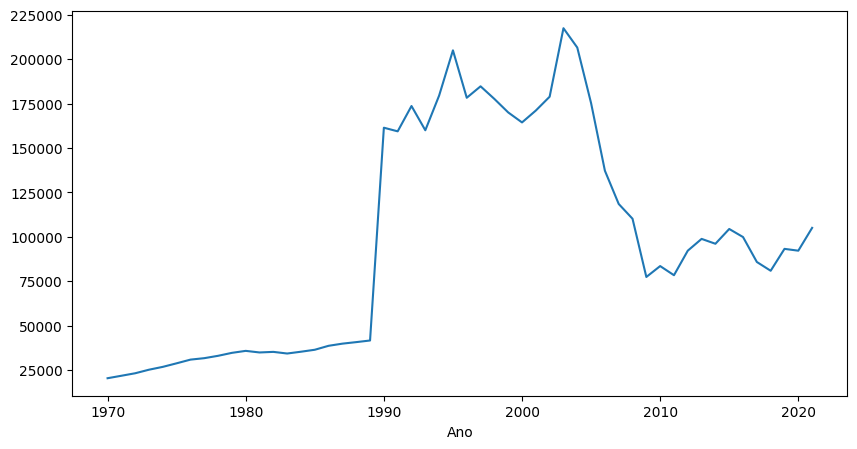

In [37]:
dados_emissoes_ano.groupby("Ano")["Emissão"].mean().plot(kind="line", figsize=(10,5), legend=False)

In [39]:
dados_emissoes_ano.groupby("Ano")["Emissão"].mean().idxmax()

np.int64(2003)

In [41]:
dados_emissoes_ano.groupby(["Ano", "Gás"])[["Emissão"]].mean()

Emissão
Ano  Gás                     
1970 C2F6 (t)        0.232610
     CF4 (t)         3.557421
     CH4 (t)      1468.366197
     CO (t)       2154.429254
     CO2 (t)     16208.866464
...                       ...
2021 HFC-23 (t)      0.000000
     HFC-32 (t)    261.100000
     N2O (t)       119.172531
     NOx (t)       744.579232
     SF6 (t)         5.240000

[1196 rows x 1 columns]

In [43]:
media_anual = dados_emissoes_ano.groupby(["Ano", "Gás"])[["Emissão"]].mean().reset_index()
media_anual

,Ano,Gás,Emissão
0,1970,C2F6 (t),0.232610
1,1970,CF4 (t),3.557421
2,1970,CH4 (t),1468.366197
3,1970,CO (t),2154.429254
4,1970,CO2 (t),16208.866464
...,...,...,...
1191,2021,HFC-23 (t),0.000000
1192,2021,HFC-32 (t),261.100000
1193,2021,N2O (t),119.172531
1194,2021,NOx (t),744.579232


In [44]:
media_anual = media_anual.pivot_table(index="Ano", columns="Gás", values="Emissão")
media_anual

Gás,C2F6 (t),CF4 (t),CH4 (t),CO (t),CO2 (t),CO2e (t) GTP-AR2,CO2e (t) GTP-AR4,CO2e (t) GTP-AR5,CO2e (t) GTP-AR6,CO2e (t) GWP-AR2,...,COVNM (t),HFC-125 (t),HFC-134a (t),HFC-143a (t),HFC-152a (t),HFC-23 (t),HFC-32 (t),N2O (t),NOx (t),SF6 (t)
Ano,,,,,,,,,,,,,,,,,,,,,
1970,0.232610,3.557421,1468.366197,2154.429254,16208.866464,18862.703799,18862.703799,17370.674172,17921.680291,31972.459540,...,741.692873,0.000000,0.000000,0.000000,0.0,0.00,0.00,31.590338,159.944249,0.000
1971,0.334611,5.117360,1522.749052,2258.483712,18146.100667,20331.726520,20331.726520,18786.502412,19360.117065,33918.077574,...,729.773925,0.000000,0.000000,0.000000,0.0,0.00,0.00,32.564894,177.219333,0.000
1972,0.404684,6.189025,1581.855297,2417.704589,19877.907343,21811.052503,21811.052503,20194.514777,20791.408670,35933.295351,...,773.908363,0.000000,0.000000,0.000000,0.0,0.00,0.00,34.265347,195.786087,0.000
1973,0.463147,7.083136,1639.621403,2594.007500,23040.103307,24008.339911,24008.339911,22338.262259,22958.289918,38637.085426,...,796.232223,0.000000,0.000000,0.000000,0.0,0.00,0.00,35.225461,217.153952,0.000
1974,0.471026,7.203619,1701.513896,2679.348234,25101.967674,25703.767093,25703.767093,23959.827151,24608.023330,40897.425131,...,1023.881477,0.000000,0.000000,0.000000,0.0,0.00,0.00,37.043361,247.348600,0.000
1975,0.502952,7.691893,1850.983878,2728.741345,26829.916884,27523.595441,27523.595441,25647.230246,26346.986093,44029.537867,...,1064.834308,0.000000,0.000000,0.000000,0.0,0.00,0.00,39.391377,262.512975,0.000
1976,0.577172,8.826970,1929.121769,2700.361944,29604.751179,29744.908577,29744.908577,27777.433491,28509.363453,46957.087965,...,1090.909415,0.000000,0.000000,0.000000,0.0,0.00,0.00,41.520218,286.788433,0.000
1977,0.692855,10.596169,1928.380995,2673.886906,31019.258454,30762.882745,30762.882745,28770.501249,29505.262188,47988.715603,...,1146.799626,0.000000,0.000000,0.000000,0.0,0.00,0.00,42.507228,292.186673,0.000
1978,0.749660,11.464915,1917.791312,2753.745425,33891.094637,32421.122637,32421.122637,30436.075836,31171.795363,49552.052838,...,1288.831742,0.000000,0.000000,0.000000,0.0,0.00,0.00,42.365242,322.773144,0.000


array([<Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>,
       <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>,
       <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>,
       <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>,
       <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>,
       <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>,
       <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>,
       <Axes: xlabel='Ano'>, <Axes: xlabel='Ano'>], dtype=object)

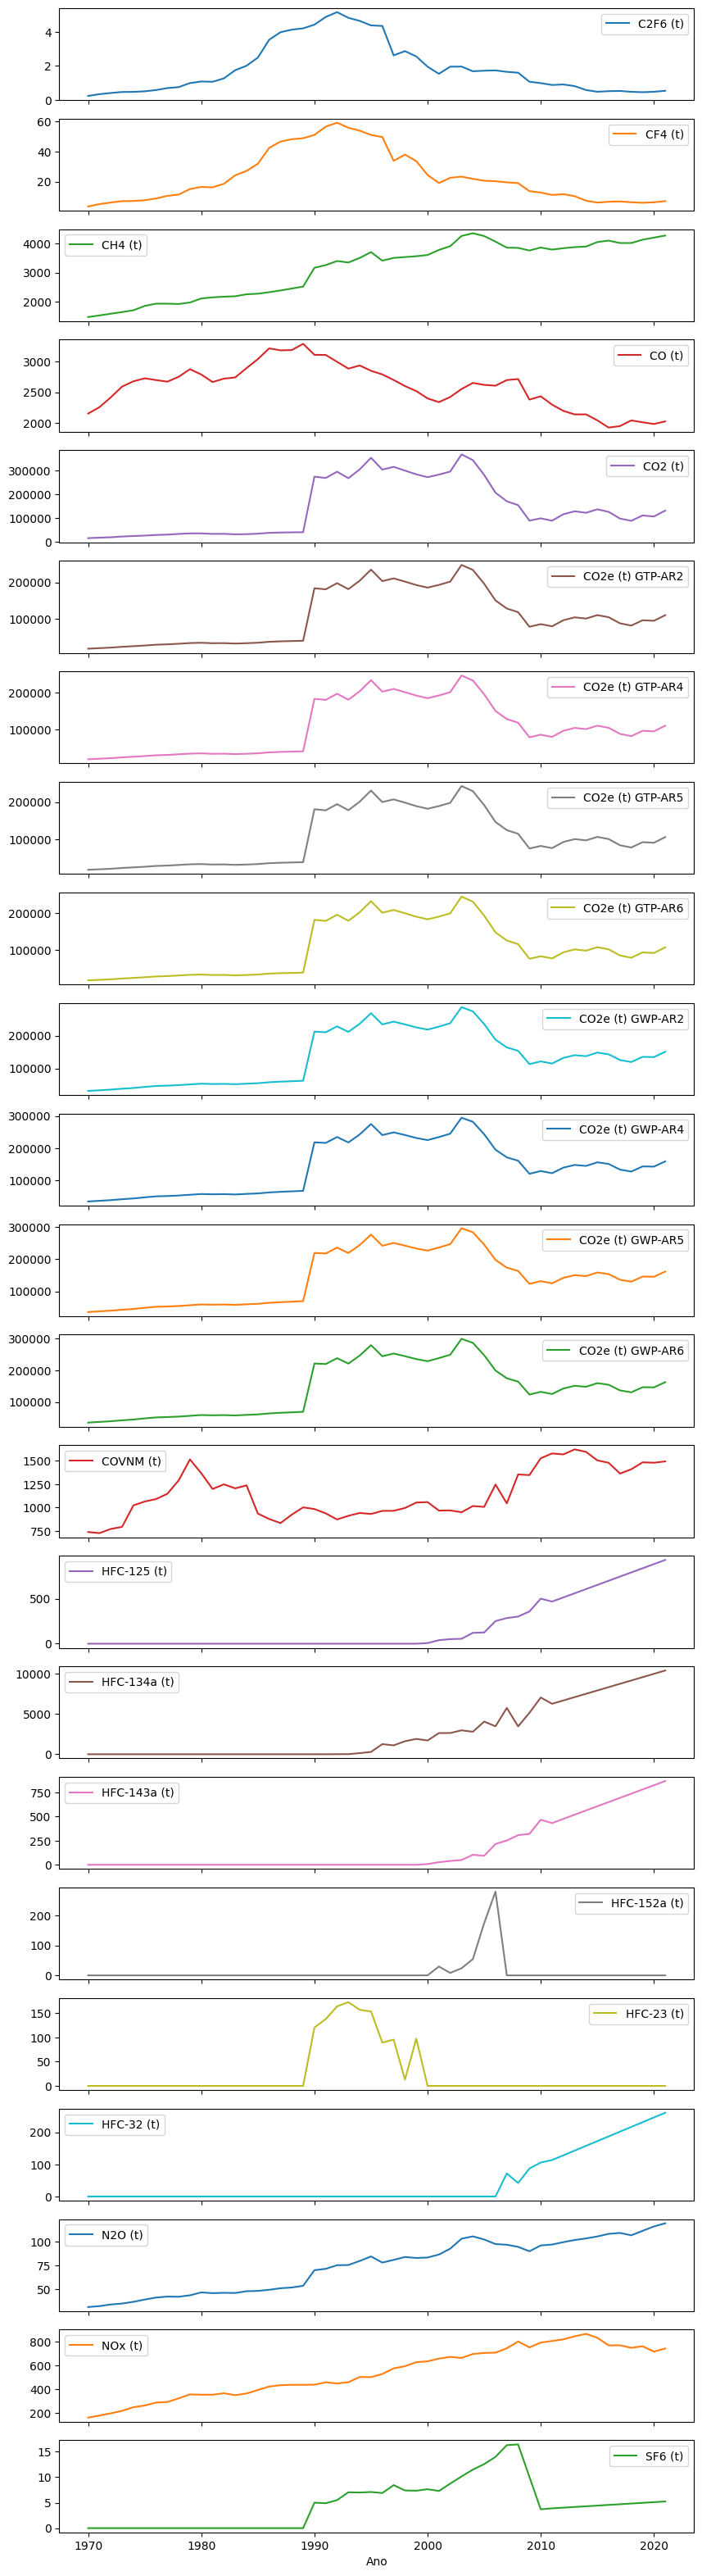

In [46]:
media_anual.plot(subplots=True, figsize=(10,40))